Algorithm Evaluation: Choosing the best model on basis of different performance metrics.

Importing all the necessary libraries


Read the dataset

In [1]:
# ignore non-harmful warnings
from warnings import filterwarnings
filterwarnings('ignore')

# To read the dataset
import pandas as pd

# To clean the data and preprocess it
# from sklearn.pipeline import make_pipeline
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import StandardScaler,OneHotEncoder
# from sklearn.compose import ColumnTransformer
from  data_clean_preprocess1 import clean_process_data


# Divide the data into training and testing
from sklearn.model_selection import train_test_split,cross_val_score

# Model buidling=> Decision Tree, Logistic Regression, Random Forest, Gradient Boost, XGBoost
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import CategoricalNB



# Evaluation metrics
from sklearn.metrics import f1_score,ConfusionMatrixDisplay,classification_report,accuracy_score

In [2]:
path = r"C:\Users\admin\Downloads\datasets-train.csv"
df = pd.read_csv(path)
df.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0


In [3]:
print(f'Shape of Data:{df.shape}')
print(f'Columns present in dataset: {df.columns}')
print(f'Info of the dataset: {df.info()}')

Shape of Data:(136429, 14)
Columns present in dataset: Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136429 entries, 0 to 136428
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       136429 non-null  int64  
 1   Product ID               136429 non-null  object 
 2   Type                     136429 non-null  object 
 3   Air temperature [K]      136429 non-null  float64
 4   Process temperature [K]  136429 non-null  float64
 5   Rotational speed [rpm]   136429 non-null  int64  
 6   Torque [Nm]              136429 non-null  float64
 7   Tool wear [min]          136429 non-null  int64  
 8   Machine failure          136429 non-


Perform basic data quality checks

In [4]:
# Missing values
print(f'Missing Values ')
df.isna().sum()

Missing Values 


id                         0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [5]:
## Duplicated rows
print(f'Duplicated rows')
df.duplicated().sum()

Duplicated rows


np.int64(0)

In [6]:
df = df.drop_duplicates()
print('Duplicated rows are dropped')

Duplicated rows are dropped


Separate X and Y features
Y: 'Machine failure'

In [7]:
df.columns

Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [8]:
df.columns=['id', 'Product ID', 'Type', 'Air temperature K',
       'Process temperature K', 'Rotational speed rpm', 'Torque Nm',
       'Tool wear min', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF']

In [9]:
X = df.drop(columns=['id','Machine failure'])
Y = df[['Machine failure']]
print(X.head())
print('-------')
print(Y.head())

  Product ID Type  Air temperature K  Process temperature K  \
0     L50096    L              300.6                  309.6   
1     M20343    M              302.6                  312.1   
2     L49454    L              299.3                  308.5   
3     L53355    L              301.0                  310.9   
4     M24050    M              298.0                  309.0   

   Rotational speed rpm  Torque Nm  Tool wear min  TWF  HDF  PWF  OSF  RNF  
0                  1596       36.1            140    0    0    0    0    0  
1                  1759       29.1            200    0    0    0    0    0  
2                  1805       26.5             25    0    0    0    0    0  
3                  1524       44.3            197    0    0    0    0    0  
4                  1641       35.4             34    0    0    0    0    0  
-------
   Machine failure
0                0
1                0
2                0
3                0
4                0


Data Preprocessing and Data cleaning

In [10]:
cat = list(X.columns[X.dtypes=='object'])
con = list(X.columns[X.dtypes!='object'])

In [11]:
from data_clean_preprocess1 import clean_process_data

In [12]:
pre,X_pre = clean_process_data(cat,con,X)
#X_pre.head()

In [13]:
pre

,transformers,"[('cat', ...), ('con', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None


In [14]:
xtrain,xtest,ytrain,ytest = train_test_split(X_pre,Y,train_size=0.75,random_state=21)
print(f'xtrain.shape: {xtrain.shape}')
print(f'xtest.shape: {xtest.shape}')
print(f'ytrain.shape: {ytrain.shape}')
print(f'ytest.shape: {ytest.shape}')

xtrain.shape: (102321, 9989)
xtest.shape: (34108, 9989)
ytrain.shape: (102321, 1)
ytest.shape: (34108, 1)


In [15]:
df['Machine failure'].value_counts()

Machine failure
0    134281
1      2148
Name: count, dtype: int64

balance the data using class_weight

Algorithm Evaluation

In [16]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score

In [17]:
models =[
    LogisticRegression(),
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    XGBClassifier(),
    BernoulliNB()
]

In [18]:

models[1]

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [19]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler()
x_us,y_us = rus.fit_resample(xtrain,ytrain)


In [20]:
x_us.head()

,cat__Product ID_H29424,cat__Product ID_H29425,cat__Product ID_H29432,cat__Product ID_H29434,cat__Product ID_H29441,cat__Product ID_H29452,cat__Product ID_H29457,cat__Product ID_H29462,cat__Product ID_H29466,cat__Product ID_H29481,...,con__Air temperature K,con__Process temperature K,con__Rotational speed rpm,con__Torque Nm,con__Tool wear min,con__TWF,con__HDF,con__PWF,con__OSF,con__RNF
17897,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.308759,0.764477,-0.773635,0.641170,-1.210180,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
104260,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.416157,0.403510,0.329178,-1.158364,0.087409,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
34955,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.892890,-1.112551,-0.852922,0.794072,-0.647370,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
4727,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.342182,0.620091,-1.069160,1.652673,0.321913,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
31987,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.624396,-0.390617,-1.047536,0.958735,0.822188,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568


In [ ]:
def evaluate_model_performance(model,x_us,y_us,xtest,ytest):
    # Fit the model
    
    model.fit(x_us,y_us)

    # Predict the outputs-Machine Failiure
    ypred_train = model.predict(x_us)
    ypred_test = model.predict(xtest)

    # Evaluation on basis of metrics: f1-score
    f1_train = f1_score(y_us,ypred_train)
    f1_test = f1_score(ytest,ypred_test)

    # Evaluate through cross validation also
    scores = cross_val_score(model,x_us,y_us,cv=4,scoring='f1_macro')
    f1_cv = scores.mean()
   
    # Accuray Score on train dataset
    accuracy_train = accuracy_score(y_us,ypred_train)
    print('accuracy_score on train dataset :',accuracy_train)

    # Accuracy Score on test dataset
    accuracy_test = accuracy_score(ytest,ypred_test ) #(x_us,ypred_test)
    print('accuracy_score on test dataset : ',accuracy_test)


    # Returns all the above results for the model
    results = {
        'Name':type(model).__name__,
        'f1-score:training':f1_train,
        'f1-score:testing':f1_test,
        'f1-cv':f1_cv,
        'accuracy_score :training': accuracy_train,
        'accuracy_score :testing ':accuracy_test 
        }
    return results

In [22]:

models

[LogisticRegression(),
 DecisionTreeClassifier(),
 RandomForestClassifier(),
 XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=None, num_parallel_tree=None, ...),
 BernoulliNB()]

In [23]:
def evaluate_model(models,x_us,y_us,xtest,ytest):
    res = []
    for m in models:
        r = evaluate_model_performance(m,x_us,y_us,xtest,ytest)

        # combine all the results of each model provided as input to above method into a res list
        res.append(r)
    # Convert these results into a dataframe and display
    results_df = pd.DataFrame(res)
    return results_df

In [24]:
score_results_df = evaluate_model(models,x_us,y_us,xtest,ytest)

accuracy_score on train dataset : 0.9185323383084577
accuracy_score on test dataset :  0.9868359329189633
accuracy_score on train dataset : 0.9990671641791045
accuracy_score on test dataset :  0.9277882021813064
accuracy_score on train dataset : 0.9990671641791045
accuracy_score on test dataset :  0.9452621085962237
accuracy_score on train dataset : 0.994092039800995
accuracy_score on test dataset :  0.9330362378327665
accuracy_score on train dataset : 0.9241293532338308
accuracy_score on test dataset :  0.8210976896915679


In [25]:
X.columns

Index(['Product ID', 'Type', 'Air temperature K', 'Process temperature K',
       'Rotational speed rpm', 'Torque Nm', 'Tool wear min', 'TWF', 'HDF',
       'PWF', 'OSF', 'RNF'],
      dtype='object')

In [26]:

score_results_df

,Name,f1-score:training,f1-score:testing,f1-cv,accuracy_score :training,accuracy_score :testing
0,LogisticRegression,0.911785,0.660620,0.900935,0.918532,0.986836
1,DecisionTreeClassifier,0.999067,0.275801,0.903526,0.999067,0.927788
2,RandomForestClassifier,0.999068,0.344682,0.921565,0.999067,0.945262
3,XGBClassifier,0.994072,0.293754,0.910369,0.994092,0.933036
4,BernoulliNB,0.923222,0.135204,0.842397,0.924129,0.821098


In [27]:

score_results_df.sort_values(by='f1-cv',ascending=False)

,Name,f1-score:training,f1-score:testing,f1-cv,accuracy_score :training,accuracy_score :testing
2,RandomForestClassifier,0.999068,0.344682,0.921565,0.999067,0.945262
3,XGBClassifier,0.994072,0.293754,0.910369,0.994092,0.933036
1,DecisionTreeClassifier,0.999067,0.275801,0.903526,0.999067,0.927788
0,LogisticRegression,0.911785,0.660620,0.900935,0.918532,0.986836
4,BernoulliNB,0.923222,0.135204,0.842397,0.924129,0.821098


Finalising XGBClassifier on basis of highest f1-cv scores

In [28]:
final_model = XGBClassifier()
final_model.fit(x_us,y_us)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [29]:
final_model.score(x_us,y_us)

0.994092039800995

In [30]:
final_model.score(xtest,ytest)

0.9330362378327665

Model Evaluation using confusion matrix, classification report, ROC-AUC curve

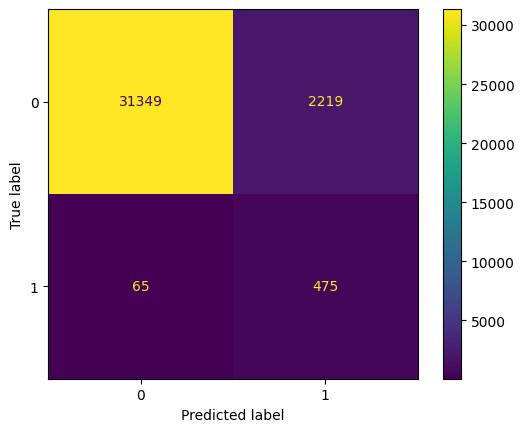

In [31]:
ConfusionMatrixDisplay.from_estimator(final_model,xtest,ytest)

In [32]:

print(classification_report(ytest,final_model.predict(xtest)))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96     33568
           1       0.18      0.88      0.29       540

    accuracy                           0.93     34108
   macro avg       0.59      0.91      0.63     34108
weighted avg       0.98      0.93      0.95     34108



In [ ]:
model_results = {
    'Actual Y Data':ytest['Machine failiure'],
    'LogisticRegression':ypred_test,
    ' DecisionTreeClassifier':ypred_test2,
    'RandomForestClassifier':
    'XGBClassifier': ypred_test3
    'BernoulliNB':
}
df_model_results = pd.DataFrame(model_results)
df_model_results

SyntaxError: invalid syntax (3146088297.py, line 6)

In [ ]:
from sklearn.metrics import roc_curve,auc
import matplotlib.pyplot as plt
for model in [LogisticRegression(),
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    XGBClassifier(),
    BernoulliNB()]:
    fpr,tpr,thresholds = roc_curve(ytest,df_model_results[model])
    roc_auc = auc(fpr,tpr)
    plt.plot(fpr,tpr,label=f'{model} AUC={roc_auc:.2f}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC and AUC curve for {model}')
    plt.legend()
    plt.show()

NameError: name 'df_model_results' is not defined

model_results = {
    'Actual Y Data':ytest['loan_status'],
    'RandomForestClassifier':ypred_test,
    'GradientBoostingClassifier':ypred_test2,
    'XGBClassifier':ypred_test3
}
df_model_results = pd.DataFrame(model_results)
df_model_results


Using this model for final predictions

In [ ]:
import pandas as pd
path2 = r'C:\Users\admin\Downloads\datasets-test.csv'
xnew = pd.read_csv(path2)
xnew.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF
0,136429,L50896,L,302.3,311.5,1499,38.0,60,0,0,0,0,0
1,136430,L53866,L,301.7,311.0,1713,28.8,17,0,0,0,0,0
2,136431,L50498,L,301.3,310.4,1525,37.7,96,0,0,0,0,0
3,136432,M21232,M,300.1,309.6,1479,47.6,5,0,0,0,0,0
4,136433,M19751,M,303.4,312.3,1515,41.3,114,0,0,0,0,0


In [ ]:
xnew.columns

Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')

In [ ]:
xnew.columns = ['id', 'Product ID', 'Type', 'Air temperature K',
       'Process temperature K', 'Rotational speed rpm', 'Torque Nm',
       'Tool wear min', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

In [ ]:

xnew_pre = pre.transform(xnew)

In [ ]:

xnew_pre.head()

,cat__Product ID_H29424,cat__Product ID_H29425,cat__Product ID_H29432,cat__Product ID_H29434,cat__Product ID_H29441,cat__Product ID_H29452,cat__Product ID_H29457,cat__Product ID_H29462,cat__Product ID_H29466,cat__Product ID_H29481,...,con__Air temperature K,con__Process temperature K,con__Rotational speed rpm,con__Torque Nm,con__Tool wear min,con__TWF,con__HDF,con__PWF,con__OSF,con__RNF
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.308759,1.125444,-0.153753,-0.276240,-0.694271,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.986567,0.764477,1.388744,-1.358313,-1.366516,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.771772,0.331317,0.033653,-0.311525,-0.131461,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.127386,-0.246230,-0.297912,0.852880,-1.554119,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.899446,1.702992,-0.038426,0.111895,0.149943,-0.03945,-0.072021,-0.049016,-0.063038,-0.047568


In [ ]:
Machine_Failiure_predicted = final_model.predict(xnew_pre)
Machine_Failiure_predicted[:5]

array([0, 0, 0, 0, 0])

In [ ]:
xnew['Machine failiure Predicted'] = Machine_Failiure_predicted
xnew.to_csv('Machine Failiure Results.csv',index=False)